# Python E-commerce Analysis

An end-to-end analysis of e-commerce orders, customers, products, and order items to uncover revenue trends, customer behavior, product performance, and ordering patterns.

**Questions explored**

- How does completed-order revenue change over time?
- Which customer segments and product categories contribute most?
- Which products lead completed line-item revenue?
- When are orders most active?

The repository dataset is privacy-safe: direct customer identifiers such as names, emails, and phone numbers were removed before publication.

## 1. Setup and data loading

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
CHART_DIR = PROJECT_ROOT / "charts"
CHART_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
COLORS = {
    "blue": "#2563EB",
    "green": "#059669",
    "gold": "#D97706",
    "red": "#DC2626",
    "violet": "#7C3AED",
    "gray": "#64748B",
}

orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
customers = pd.read_csv(DATA_DIR / "customers.csv", parse_dates=["signup_date"])
products = pd.read_csv(DATA_DIR / "products.csv")
order_items = pd.read_csv(DATA_DIR / "order_items.csv")

dataset_summary = pd.DataFrame({
    "dataset": ["orders", "customers", "products", "order_items"],
    "rows": [len(orders), len(customers), len(products), len(order_items)],
    "columns": [orders.shape[1], customers.shape[1], products.shape[1], order_items.shape[1]],
})
dataset_summary

Unable to revert mtime: /Library/Fonts


Matplotlib is building the font cache; this may take a moment.


,dataset,rows,columns
0,orders,5020,5
1,customers,1200,4
2,products,200,5
3,order_items,9423,5


## 2. Data quality and cleaning

In [2]:
quality_report = pd.DataFrame({
    "dataset": ["orders", "customers", "products", "order_items"],
    "duplicate_ids": [
        orders["id"].duplicated().sum(),
        customers["id"].duplicated().sum(),
        products["id"].duplicated().sum(),
        order_items["id"].duplicated().sum(),
    ],
    "missing_values": [
        orders.isna().sum().sum(),
        customers.isna().sum().sum(),
        products.isna().sum().sum(),
        order_items.isna().sum().sum(),
    ],
})
quality_report

,dataset,duplicate_ids,missing_values
0,orders,20,200
1,customers,0,48
2,products,0,0
3,order_items,0,0


In [3]:
# Standardize labels, remove duplicate primary keys, and keep missing revenue as null.
orders_clean = orders.copy()
orders_clean["status"] = orders_clean["status"].str.lower().str.strip()
orders_clean = orders_clean.drop_duplicates(subset="id", keep="first")

customers_clean = customers.copy()
customers_clean["country"] = customers_clean["country"].fillna("Unknown")

products_clean = products.drop_duplicates(subset="id", keep="first").copy()
order_items_clean = order_items.drop_duplicates(subset="id", keep="first").copy()

# Enforce valid relationships after cleaning.
order_items_clean = order_items_clean[
    order_items_clean["order_id"].isin(orders_clean["id"])
    & order_items_clean["product_id"].isin(products_clean["id"])
]

print(f"Orders: {len(orders):,} -> {len(orders_clean):,}")
print(f"Missing order totals retained: {orders_clean['total_amount'].isna().sum():,}")
print(f"Order date range: {orders_clean['order_date'].min():%Y-%m-%d} to {orders_clean['order_date'].max():%Y-%m-%d}")

Orders: 5,020 -> 5,000
Missing order totals retained: 200
Order date range: 2023-01-01 to 2024-12-30


### Cleaning decisions

- Status labels are normalized to lowercase and stripped of extra spaces.
- Duplicate order IDs are reduced to the first occurrence.
- Missing countries are labeled `Unknown`.
- Missing order totals are **not imputed**. They remain in order counts but are excluded naturally from revenue sums and averages.
- Order items with invalid order or product references are removed.

## 3. Revenue trend

In [4]:
completed_orders = orders_clean.query("status == 'completed'").copy()
completed_with_revenue = completed_orders.dropna(subset=["total_amount"]).copy()

monthly_revenue = (
    completed_with_revenue
    .assign(month=lambda frame: frame["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(
        revenue=("total_amount", "sum"),
        orders=("id", "count"),
        average_order_value=("total_amount", "mean"),
    )
)
monthly_revenue["mom_growth_pct"] = monthly_revenue["revenue"].pct_change() * 100
monthly_revenue

,month,revenue,orders,average_order_value,mom_growth_pct
0,2023-01-01,92062.34,134,687.032388,NaN
1,2023-02-01,82749.52,116,713.357931,-10.115776
2,2023-03-01,69864.50,104,671.774038,-15.571111
3,2023-04-01,76291.52,114,669.223860,9.199264
4,2023-05-01,88555.56,117,756.885128,16.075234
5,2023-06-01,186364.24,133,1401.234887,110.448943
6,2023-07-01,145277.36,138,1052.734493,-22.046547
7,2023-08-01,95112.19,139,684.260360,-34.530618
8,2023-09-01,74481.48,111,671.004324,-21.690921
9,2023-10-01,156309.94,121,1291.817686,109.864170


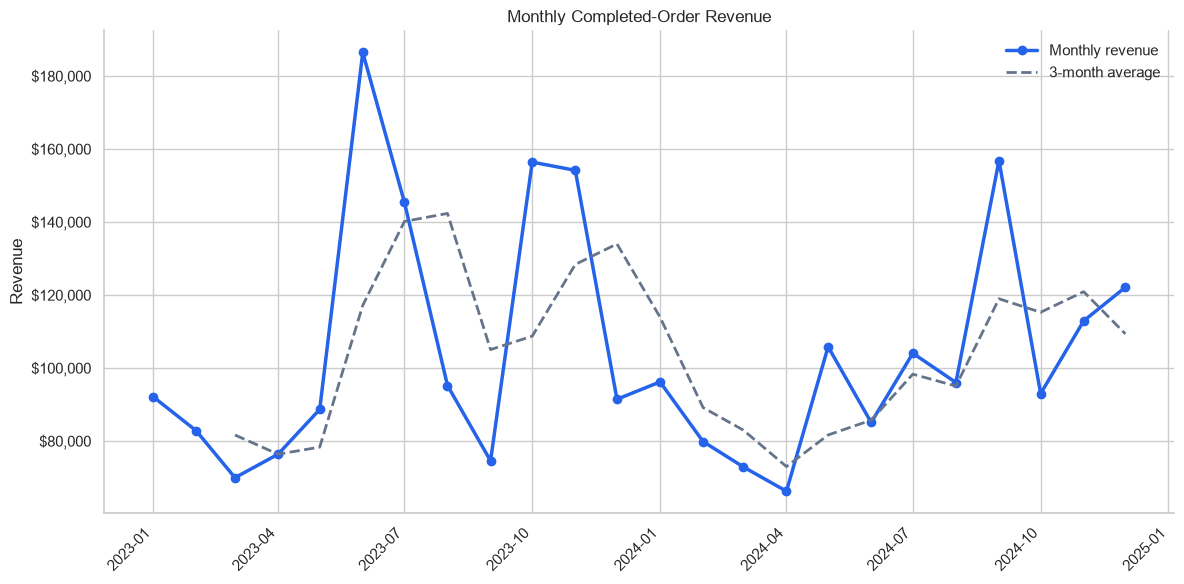

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_revenue["month"], monthly_revenue["revenue"],
        color=COLORS["blue"], linewidth=2.5, marker="o", label="Monthly revenue")
ax.plot(monthly_revenue["month"], monthly_revenue["revenue"].rolling(3).mean(),
        color=COLORS["gray"], linewidth=2, linestyle="--", label="3-month average")
ax.set(title="Monthly Completed-Order Revenue", xlabel="", ylabel="Revenue")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.autofmt_xdate(rotation=45)
fig.tight_layout()
fig.savefig(CHART_DIR / "monthly_revenue.png", dpi=160, bbox_inches="tight")
plt.show()

In [6]:
peak_month = monthly_revenue.loc[monthly_revenue["revenue"].idxmax()]
low_month = monthly_revenue.loc[monthly_revenue["revenue"].idxmin()]
print(f"Completed-order revenue: ${completed_with_revenue['total_amount'].sum():,.2f}")
print(f"Average order value: ${completed_with_revenue['total_amount'].mean():,.2f}")
print(f"Peak month: {peak_month['month']:%B %Y} (${peak_month['revenue']:,.2f})")
print(f"Lowest month: {low_month['month']:%B %Y} (${low_month['revenue']:,.2f})")
print(f"Average month-over-month growth: {monthly_revenue['mom_growth_pct'].mean():.1f}%")

Completed-order revenue: $2,502,349.32
Average order value: $840.00
Peak month: June 2023 ($186,364.24)
Lowest month: April 2024 ($66,147.79)
Average month-over-month growth: 7.7%


**Interpretation:** Revenue fluctuates sharply rather than following a sustained upward trend. The positive average monthly growth rate is influenced by several rebounds after weak months, so it should not be read as steady growth.

## 4. Customer analysis

In [7]:
customer_metrics = (
    completed_with_revenue
    .groupby("customer_id", as_index=False)
    .agg(
        completed_orders=("id", "count"),
        total_spent=("total_amount", "sum"),
        average_order_value=("total_amount", "mean"),
        first_order=("order_date", "min"),
        last_order=("order_date", "max"),
    )
)

one_time = (customer_metrics["completed_orders"] == 1).sum()
repeat = (customer_metrics["completed_orders"] > 1).sum()
print(f"Customers with a known completed-order total: {len(customer_metrics):,}")
print(f"One-time buyers: {one_time:,} ({one_time / len(customer_metrics):.1%})")
print(f"Repeat buyers: {repeat:,} ({repeat / len(customer_metrics):.1%})")

Customers with a known completed-order total: 1,100
One-time buyers: 245 (22.3%)
Repeat buyers: 855 (77.7%)


In [8]:
orders_with_customers = completed_with_revenue.merge(
    customers_clean[["id", "country", "segment"]],
    left_on="customer_id",
    right_on="id",
    how="left",
    suffixes=("", "_customer"),
)

customer_segments = (
    orders_with_customers
    .groupby("segment", as_index=False)
    .agg(customers=("customer_id", "nunique"), orders=("id", "count"), revenue=("total_amount", "sum"))
    .sort_values("revenue", ascending=False)
)
customer_segments

,segment,customers,orders,revenue
0,consumer,431,1185,965950.58
3,smb,292,766,666838.62
2,mid-market,236,632,596047.01
1,enterprise,141,396,273513.11


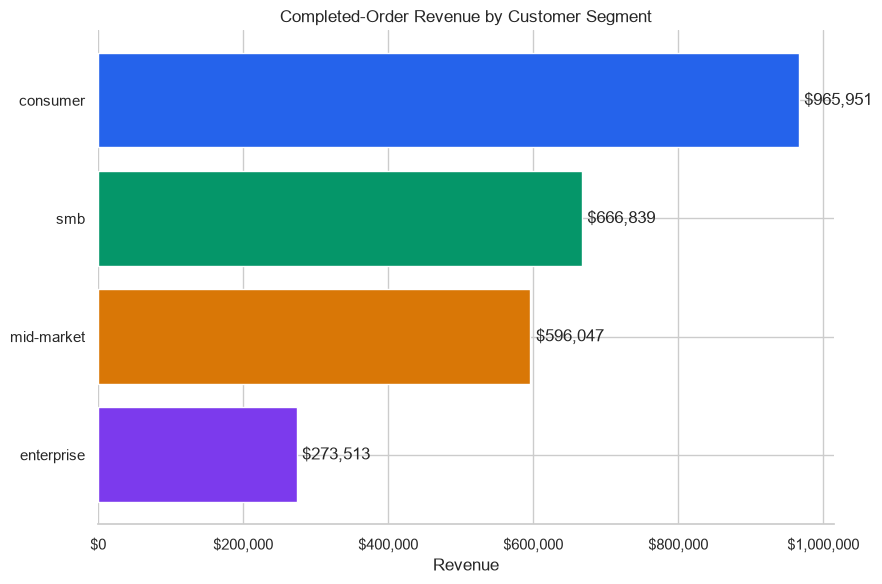

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
segment_plot = customer_segments.sort_values("revenue")
bars = ax.barh(segment_plot["segment"], segment_plot["revenue"],
               color=[COLORS["violet"], COLORS["gold"], COLORS["green"], COLORS["blue"]])
ax.bar_label(bars, labels=[f"${value:,.0f}" for value in segment_plot["revenue"]], padding=4)
ax.set(title="Completed-Order Revenue by Customer Segment", xlabel="Revenue", ylabel="")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.spines[["top", "right", "left"]].set_visible(False)
fig.tight_layout()
fig.savefig(CHART_DIR / "customer_segments.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Product and category performance

In [10]:
completed_items = order_items_clean.merge(
    completed_orders[["id"]], left_on="order_id", right_on="id", how="inner", suffixes=("", "_order")
)
completed_items["line_revenue"] = completed_items["quantity"] * completed_items["unit_price"]

product_performance = (
    completed_items
    .groupby("product_id", as_index=False)
    .agg(units_sold=("quantity", "sum"), line_revenue=("line_revenue", "sum"), orders=("order_id", "nunique"))
    .merge(products_clean[["id", "name", "category"]], left_on="product_id", right_on="id", how="left")
    .sort_values("line_revenue", ascending=False)
)

category_performance = (
    product_performance.groupby("category", as_index=False)
    .agg(line_revenue=("line_revenue", "sum"), units_sold=("units_sold", "sum"))
    .sort_values("line_revenue", ascending=False)
)
category_performance

,category,line_revenue,units_sold
3,Desks,2151645.98,2198
5,Laptops,1606284.57,1342
2,Chargers,945361.69,699
0,Cases,816746.55,839
4,Headphones,671418.44,867
9,Tablets,619952.71,583
1,Chairs,536810.49,789
7,Phones,526864.17,2229
8,Software,395651.64,421
6,Monitors,345588.27,356


`line_revenue` is calculated from order-item quantity and unit price. It is kept separate from the order-level `total_amount` because the source tables do not reconcile exactly, indicating different definitions or synthetic-data inconsistencies.

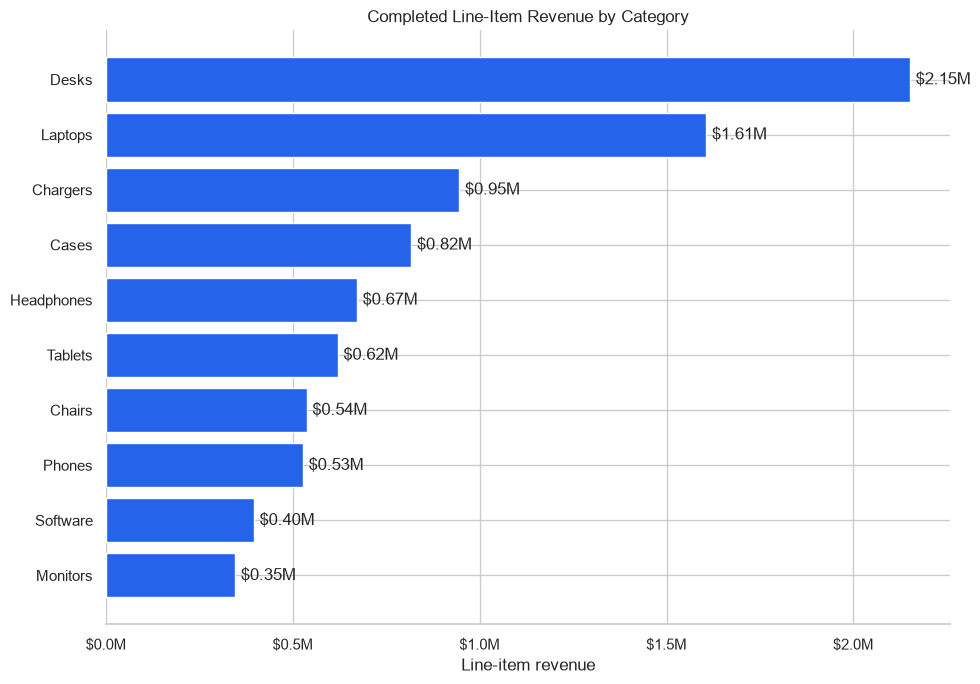

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
category_plot = category_performance.sort_values("line_revenue")
bars = ax.barh(category_plot["category"], category_plot["line_revenue"], color=COLORS["blue"])
ax.bar_label(bars, labels=[f"${value / 1_000_000:.2f}M" for value in category_plot["line_revenue"]], padding=4)
ax.set(title="Completed Line-Item Revenue by Category", xlabel="Line-item revenue", ylabel="")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f"${value / 1_000_000:.1f}M"))
ax.spines[["top", "right", "left"]].set_visible(False)
fig.tight_layout()
fig.savefig(CHART_DIR / "revenue_by_category.png", dpi=160, bbox_inches="tight")
plt.show()

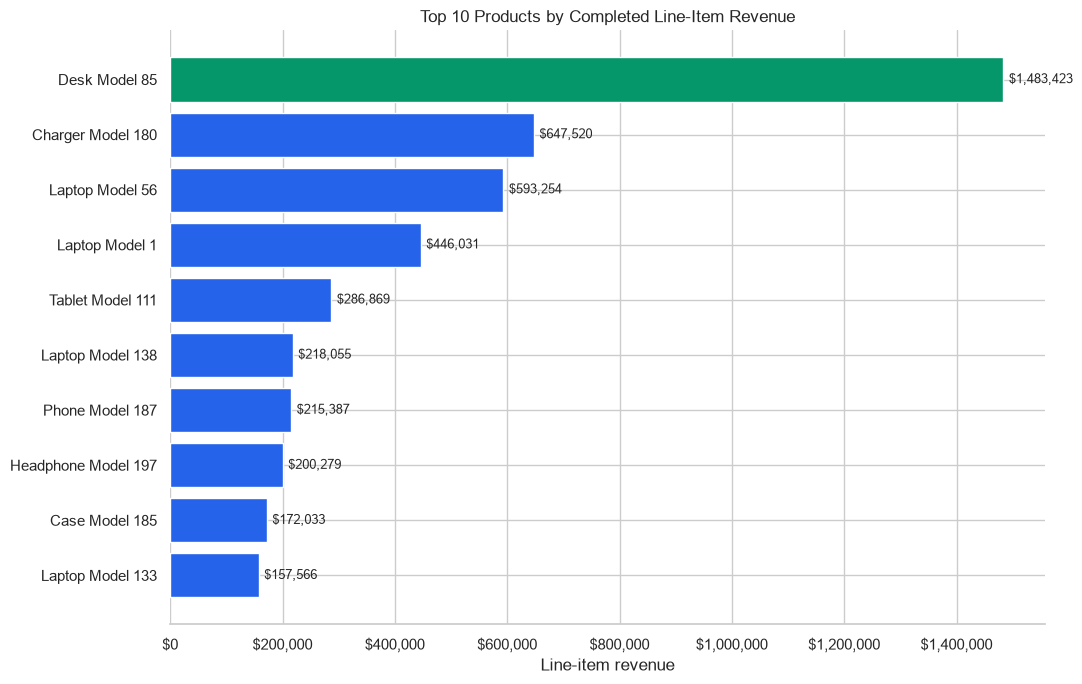

,name,category,units_sold,line_revenue
83,Desk Model 85,Desks,974,1483423.39
178,Charger Model 180,Chargers,388,647519.78
54,Laptop Model 56,Laptops,450,593253.65
0,Laptop Model 1,Laptops,250,446030.66
109,Tablet Model 111,Tablets,209,286868.70
136,Laptop Model 138,Laptops,142,218054.81
185,Phone Model 187,Phones,1887,215386.82
194,Headphone Model 197,Headphones,105,200278.52
183,Case Model 185,Cases,153,172032.59
131,Laptop Model 133,Laptops,84,157565.84


In [12]:
top_10 = product_performance.head(10).sort_values("line_revenue")
fig, ax = plt.subplots(figsize=(11, 7))
colors = [COLORS["green"] if name == product_performance.iloc[0]["name"] else COLORS["blue"] for name in top_10["name"]]
bars = ax.barh(top_10["name"], top_10["line_revenue"], color=colors)
ax.bar_label(bars, labels=[f"${value:,.0f}" for value in top_10["line_revenue"]], padding=4, fontsize=9)
ax.set(title="Top 10 Products by Completed Line-Item Revenue", xlabel="Line-item revenue", ylabel="")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.spines[["top", "right", "left"]].set_visible(False)
fig.tight_layout()
fig.savefig(CHART_DIR / "top_10_products.png", dpi=160, bbox_inches="tight")
plt.show()

product_performance[["name", "category", "units_sold", "line_revenue"]].head(10)

## 6. Ordering patterns

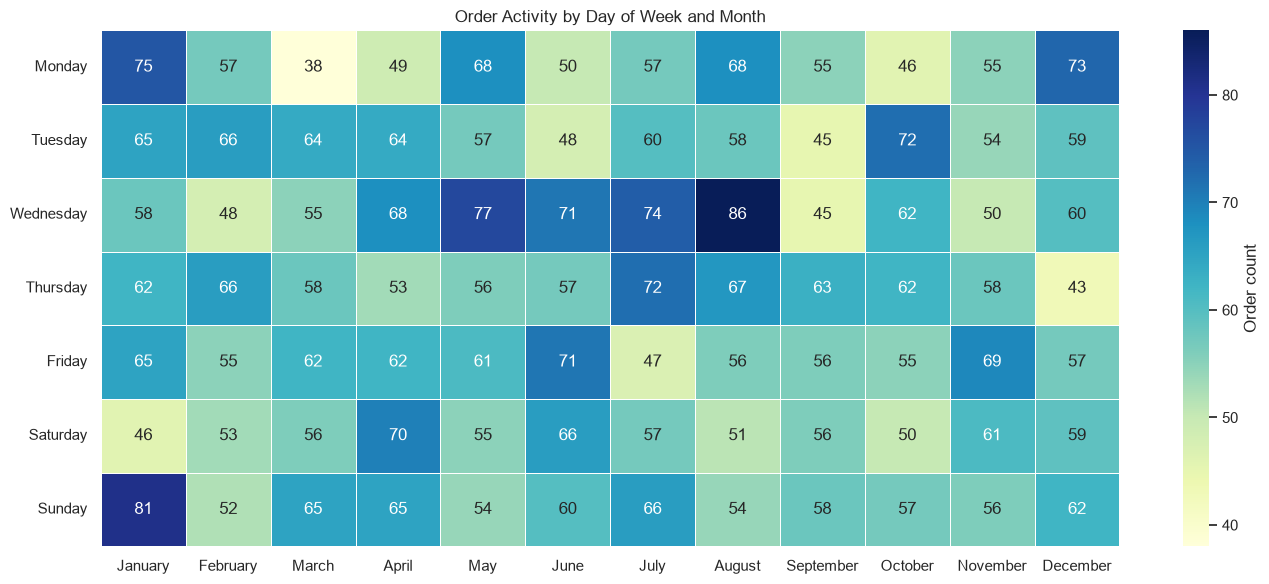

In [13]:
orders_clean["day_of_week"] = pd.Categorical(
    orders_clean["order_date"].dt.day_name(),
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True,
)
orders_clean["month_name"] = pd.Categorical(
    orders_clean["order_date"].dt.month_name(),
    categories=["January", "February", "March", "April", "May", "June",
                "July", "August", "September", "October", "November", "December"],
    ordered=True,
)

heatmap_data = orders_clean.pivot_table(
    values="id", index="day_of_week", columns="month_name", aggfunc="count", observed=False
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=True, fmt=".0f", linewidths=0.5,
            cbar_kws={"label": "Order count"}, ax=ax)
ax.set(title="Order Activity by Day of Week and Month", xlabel="", ylabel="")
fig.tight_layout()
fig.savefig(CHART_DIR / "orders_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Key findings

In [14]:
top_segment = customer_segments.iloc[0]
top_category = category_performance.iloc[0]
top_product = product_performance.iloc[0]

findings = [
    f"Known completed-order revenue totaled ${completed_with_revenue['total_amount'].sum():,.0f} across {len(completed_with_revenue):,} orders.",
    f"{peak_month['month']:%B %Y} was the peak month at ${peak_month['revenue']:,.0f}; revenue was volatile rather than steadily growing.",
    f"The {top_segment['segment']} segment led order-level revenue with ${top_segment['revenue']:,.0f}.",
    f"Repeat buyers represented {repeat / len(customer_metrics):.1%} of customers with known completed-order totals.",
    f"{top_product['name']} led completed line-item revenue at ${top_product['line_revenue']:,.0f}, while {top_category['category']} was the top category.",
]

for finding in findings:
    print(f"- {finding}")

- Known completed-order revenue totaled $2,502,349 across 2,979 orders.
- June 2023 was the peak month at $186,364; revenue was volatile rather than steadily growing.
- The consumer segment led order-level revenue with $965,951.
- Repeat buyers represented 77.7% of customers with known completed-order totals.
- Desk Model 85 led completed line-item revenue at $1,483,423, while Desks was the top category.


## Conclusion

The business has a strong repeat-customer base, but monthly revenue volatility deserves attention. Consumer customers contribute the most order-level revenue, while desks dominate completed line-item revenue. A practical next step is to investigate the causes of monthly swings and reconcile order totals with item-level values before using the data for financial reporting.